<a href="https://colab.research.google.com/github/raisa1521/Hands-on-Machine-Learning/blob/main/6%EC%9E%A5_%EA%B2%B0%EC%A0%95%ED%8A%B8%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **6장 결정 트리**

**결정 트리(Decision Tree)** : 분류와 회귀 작업, 다중 출력 작업까지 가능한 다목적 머신러닝 알고리즘

- 매우 복잡한 데이터셋도 학습할 수 있음
- 제한하지 않으면 훈련 데이터에 과대적합될 수 있음
- 랜덤 포레스트의 기본 구성 요소

## **6.1 결정 트리 학습과 시각화**

붓꽃 데이터셋에 DecisionTreeClassifier를 훈련해 결정 트리 만들기

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)

X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [3]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=["꽃잎 길이(cm)", "꽃잎 너비(cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

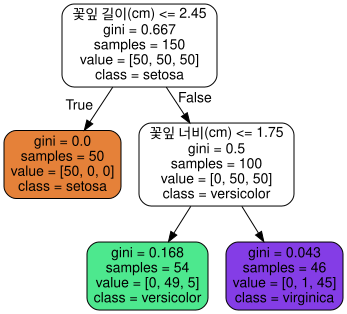

In [4]:
from graphviz import Source

Source.from_file("iris_tree.dot")

## **6.2 예측**

결정 트리는 루트 노드에서 시작하여 각 조건에 따라 왼쪽 또는 오른쪽 자식 노드로 이동하면서 예측

- 루트 노드: 깊이가 0인 맨 위의 노드
- 자식 노드 : 현재 노드 아래에 연결된 노드
- 리프 노드 : 자식 노드를 가지지 않는 노드
- 분할 노드 : 추가적인 조건 검사를 수행하는 노드

붓꽃 결정 트리의 첫 번째 조건은 꽃잎 길이가 2.45cm보다 짧은지 확인하는 것이다.

꽃잎 길이 2.45보다 작으면 -> 왼쪽 리프 노드로 이동, Iris-Setosa로 예측

꽃잎 길이 2.45보다 크면 -> 오른쪽 자식 노드로 이동, 꽃잎 너비가 1.75cm보다 작은지 다시 검사

꽃잎 너비 1.75보다 작으면 -> Iris-Versicolor
크면 -> Iris-Virginica

결정 트리의 장점 : 데이터 전처리가 거의 필요X  특성의 스케일을 맞추거나 평균을 원점에 맞추는 작업이 필요 X

###6-1 지니 불순도

$G_i=1-\sum_{k=1}^{n}p_{i,k}^2$

$G_i$ : i번째 노드의 지니 불순도


$p_{i,k}$ : i번째 노드의 훈련 샘플 중 클래스 k에 속한 샘플의 비율

## **6.3 클래스 확률 추정**

결정 트리는 샘플이 특정 클래스 k에 속할 확률도 추정 가능

1. 샘플이 도달하는 리프 노드를 찾음
2. 해당 리프 노드에서 클래스 k에 속하는 훈련 샘플의 비율을 반환

예시

꽃잎 길이가 5cm이고 너비가 1.5인 경우 도달하는 리프 노드에는 총 54개의 훈련 샘플

- Iris-Setosa : 0%
- Iris-Versicolor : 90.7%
- Iris-Virginica : 9.3%

가장 높은 확률을 가진 Iris-Versicolor 예측

In [5]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [6]:
tree_clf.predict([[5, 1.5]])

array([1])

=> 추정된 클래스 확률이 동일

## **6.5 계산 복잡도**

예측을 하려면 결정 트리의 루트 노드에서 리프 노드까지 탐색

일반적으로 결정 트리는 거의 균형을 이루므로 약 O(log_2(m))개의 노드를 거침.
각 노드는 하나의 특성값만 확인-> 예측에 필요한 전체 복잡도는 특성 수와 무관하게 O(log_2(m))

-> 큰 훈련 세트에서도 예측 속도가 매우 빠름

훈련 과정에서는 각 노드에서 훈련 샘플의 모든 특성을 비교

각 노드에서 모든 샘플의 모든 특성을 비교할 경우 훈련 복잡도는
O(n*mlog_2(m))


## **6.6 지니 불순도 또는 엔트로피**


criterion=entropy로 지정하면 엔트로피 사용 가능

엔트로피는 원래 열역학에서 분자의 무질서함을 측정하는 개념

머신러닝에서는 불순도를 측정하는 방법으로 사용 - 한 클래스의 샘플만 포함한 세트에서는 엔트로피가 0

엔트로피

$H_i=-\sum_{\substack{k=1\\p_{i,k}\neq0}}^{n}p_{i,k}\log_2(p_{i,k})$

### **지니 불순도와 엔트로피**

실제로 두 기준의 차이는 크지 않으며 비슷한 트리를 만듬

- 지니 불순도 : 계산이 조금 더 빠르므로 기본값으로 적합, 가장 빈도가 높은 클래스를 한쪽 가지로 고립시키는 경향이 있음
- 엔트로피 : 조금 더 균형 잡힌 트리를 만드는 경향

## **6.7 규제 매개변수**

결정 트리는 훈련 데이터에 대한 제약이 거의 X -> 제한하지 않으면 훈련 데이터에 아주 가깝게 맞추려 하여 과대적합되기 쉬움

- 비파라미터 모델 : 훈련되기 전에 모델 파라미터 수가 정해져 있지 않아 모델 구조가 데이터에 맞춰 자유롭게 변하는 모델

- 파라미터 모델 : 모델 파라미터 수가 미리 정해져 있어 자유도가 제한

-> 과대적합 위험은 줄어들지만 과소적합 위험은 커짐

결정 트리의 과대적합을 피하려면 트리의 자유도를 제한하는 '규제' 필요

### **결정 트리의 규제 하이퍼파라미터**

max_depth : 결정 트리의 최대 깊이

- 기본값 None -> 최대 깊이에 제한 없음
- max_depth 감소 -> 규제 증가 -> 과대적합 위험 감소

그 외

- max_features : 각 노드에서 분할에 사용할 특성의 최대 수
- max_leaf_nodes : 리프 노드의 최대 수
- min_samples_split : 분할되기 위해 노드가 가져야 하는 최소 샘플 수
- min_samples_leaf : 리프 노드가 생성되기 위해 가져야 하는 최소 샘플 수
- min_weight_fraction_leaf : min_samples_leaf와 같지만 가중치가 부여된 전체 샘플 수에서의 비율

min`으로 시작하는 매개변수 증가 → 규제 증가

max_로 시작하는 매개변수 감소 → 규제 증가

In [7]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(
    n_samples=150,
    noise=0.2,
    random_state=42
)

tree_clf1 = DecisionTreeClassifier(random_state=42)

tree_clf2 = DecisionTreeClassifier(
    min_samples_leaf=5,
    random_state=42
)

tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

In [8]:
X_moons_test, y_moons_test = make_moons(
    n_samples=1000,
    noise=0.2,
    random_state=43
)

tree_clf1.score(X_moons_test, y_moons_test)

0.898

In [9]:
tree_clf2.score(X_moons_test, y_moons_test)

0.92

->테스트 세트에서 규제를 추가한 두 번째 결정 트리의 정확도가 더 높음

### **가지치기**

제한 없이 결정 트리를 훈련한 다음 불필요한 노드를 제거하는 것

순도를 높이는 것이 통계적으로 큰 효과 X일때 리프 노드 바로 위의 노드를 불필요한 것으로 봄

대표적으로 x**2 검정과 같은 통계적 검정을 사용하여 순도 향상이 우연에 의한 것인지 추정 가능

p값이 임곗값보다 높으면 해당 노드를 불필요한 것으로 간주하고 자식 노드를 삭제

이 과정을 불필요한 노드가 없어질 때까지 반복

## **6.8 회귀**

결정 트리는 회귀 문제에도 사용 가능

잡음이 섞인 2차 함수 형태의 데이터셋에 회귀 트리를 훈련

In [11]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)

X_quad = np.random.rand(200, 1) - 0.5  # 랜덤한 하나의 입력 특성
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1)

tree_reg = DecisionTreeRegressor(
    max_depth=2,
    random_state=42
)

tree_reg.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=2, random_state=42)

분류와 마찬가지로 회귀 결정 트리도 과대적합되기 쉬움

규제가 없으면 훈련 세트에 크게 과대적합될 수 있

min_samples_leaf=10으로 지정하면 모델을 규제하여 더 그럴싸한 예측 가능

## **6.9 축 방향에 대한 민감성**

결정 트리는 계단 모양의 결정 경계를 만들며 모든 분할은 축에 수직

->  데이터의 방향에 민감

같은 데이터셋을 회전시키면 데이터 자체는 선형적으로 구분할 수 있어도 결정 트리의 결정 경계가 불필요하게 복잡해질 수 있음

이 문제 해결법

1. 데이터의 스케일을 조정
2. 주성분 분석(PCA) 변환을 적용

PCA는 특성 간의 상관관계를 줄이는 방식 -> 데이터를 회전시켜 결정 트리가 데이터를 다루기 쉽게 함(항상 X)

In [12]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pca_pipeline = make_pipeline(
    StandardScaler(),
    PCA()
)

X_iris_rotated = pca_pipeline.fit_transform(X_iris)

tree_clf_pca = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

tree_clf_pca.fit(X_iris_rotated, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

→ 데이터를 스케일링하고 PCA로 회전한 뒤 결정 트리를 훈련

## **6.10 결정 트리의 분산 문제**

결정 트리의 문제 - 분산이 상당히 큰 것

-> 하이퍼파라미터나 데이터를 조금만 변경해도 매우 다른 모델이 만들어질 수 있음

사이킷런의 훈련 알고리즘에는 확률적인 요소가 있어서 random_state 설정하지 않으면 동일한 데이터에서 동일한 결정 트리를 다시 훈련해도 다른 모델이 만들어짐

여러 결정 트리의 예측을 평균하면 분산을 크게 줄일 수 있음

이런 결정 트리의 앙상블 = 랜덤 포레스트